## Model Selection

An XGBoost Regressor was used due to its strong performance in structured data problems.

XGBoost is an ensemble learning method that builds multiple decision trees and combines them to improve prediction accuracy.

Key advantages:
- Handles non-linear relationships
- Robust to noise
- Works well with tabular data

In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
import os

sys.path.append(os.path.abspath(".."))

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [149]:
df = pd.read_csv("../data/processed_data.csv")

# because the index can now be a regular number instead of a date.
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.set_index("Datetime")

In [150]:
features = [
    "hour",
    "day_of_week",
    "month",
    "day_of_year",
    "lag_24",
    "lag_168",
    "rolling_mean_24",
    "rolling_mean_168"
]

target = "PJME_MW"

In [133]:
split_date = "2015-01-01"

train = df[df.index < split_date]
test = df[df.index >= split_date]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (113758, 8)
Test shape: (31440, 8)


## Model Evaluation

The model performance was evaluated using:

- **MAE (Mean Absolute Error)**: Average prediction error
- **RMSE (Root Mean Squared Error)**: Penalizes larger errors more heavily

These metrics provide insight into how close predictions are to actual values.

In [134]:
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [135]:
pred_xgb = model.predict(X_test)

In [136]:
# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
pred_linear = linear_model.predict(X_test)

# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
pred_rf = rf_model.predict(X_test)

## Results

The model successfully captured the general trend of electricity demand.

The predicted values closely follow the actual values, indicating that the model learned key temporal patterns.

However, small deviations can be observed during peak demand periods, suggesting opportunities for further improvement.

In [137]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.3f}")

evaluate("Linear", y_test, pred_linear)
evaluate("Random Forest", y_test, pred_rf)
evaluate("XGBoost", y_test, pred_xgb)

Linear -> MAE: 1744.06, RMSE: 2305.14, R2: 0.872
Random Forest -> MAE: 1290.72, RMSE: 1748.34, R2: 0.927
XGBoost -> MAE: 1297.72, RMSE: 1734.73, R2: 0.928


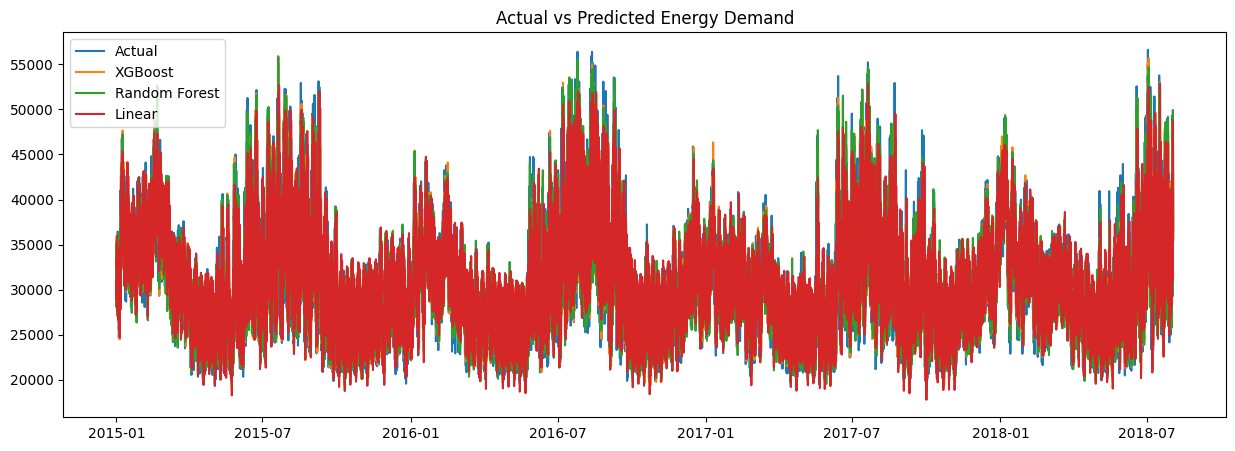

In [139]:
plt.figure(figsize=(15,5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, pred_xgb, label="XGBoost")
plt.plot(y_test.index, pred_rf, label="Random Forest")
plt.plot(y_test.index, pred_linear, label="Linear")
plt.legend()
plt.title("Actual vs Predicted Energy Demand")
plt.show()


In [140]:
print("Top Features Comparison:")

print("\nXGBoost:")
print(importance.sort_values(ascending=False).head(5))

print("\nRandom Forest:")
print(rf_importance.sort_values(ascending=False).head(5))

Top Features Comparison:

XGBoost:
lag_24             0.668564
lag_168            0.178638
rolling_mean_24    0.054962
day_of_week        0.033807
hour               0.030464
dtype: float32

Random Forest:
lag_24             0.706559
lag_168            0.110052
rolling_mean_24    0.080545
hour               0.039346
day_of_week        0.031371
dtype: float64


Both XGBoost and Random Forest emphasize lag-based features, confirming that past energy consumption strongly influences future demand.

Minor differences between models indicate that tree-based methods capture temporal dependencies similarly.

## Feature Importance

Feature importance analysis shows which variables contribute most to predictions.

Lag features (especially 24-hour lag) are highly influential, indicating strong daily patterns in electricity demand.

Rolling averages also provide valuable smoothing information.

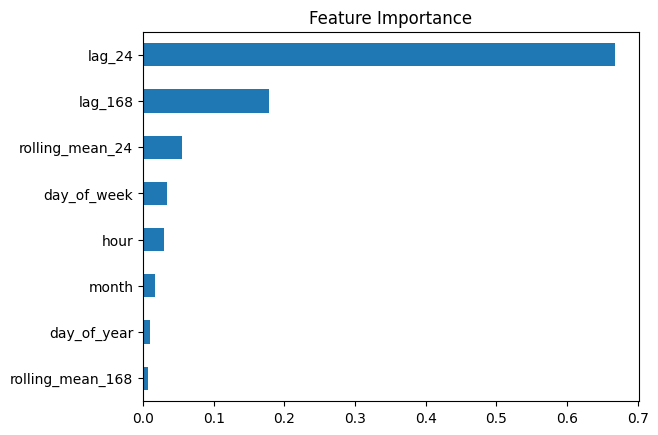

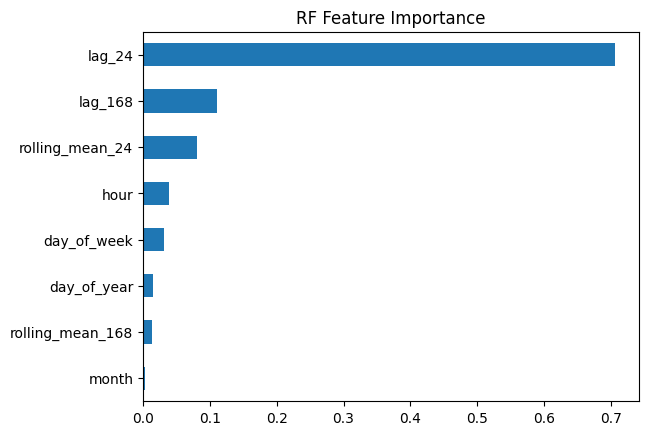

In [141]:
importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind="barh", title="Feature Importance")
plt.show()

rf_importance = pd.Series(rf_model.feature_importances_, index=features)

rf_importance.sort_values().plot(kind="barh", title="RF Feature Importance")
plt.show()

In [142]:
top_features = importance.sort_values(ascending=False).head(3)

print("Top 3 Most Important Features:")
print(top_features)
print("\nInsight:")
print("Lag features dominate, meaning past energy values strongly influence predictions.")
print("Rolling averages help smooth fluctuations.")

Top 3 Most Important Features:
lag_24             0.668564
lag_168            0.178638
rolling_mean_24    0.054962
dtype: float32

Insight:
Lag features dominate, meaning past energy values strongly influence predictions.
Rolling averages help smooth fluctuations.


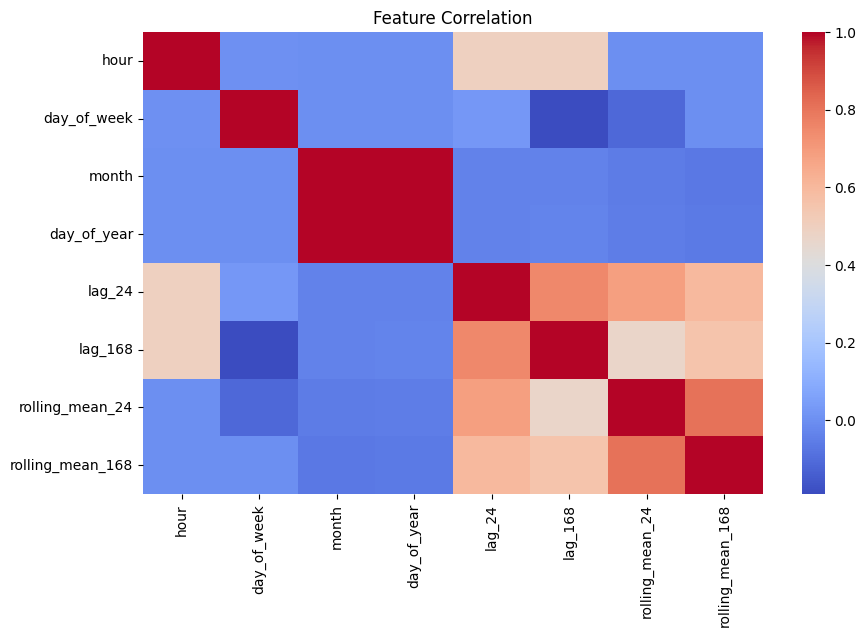

In [143]:
import seaborn as sns

corr = X_train.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

Conclusion:

Among all models, XGBoost achieved the best overall performance with the lowest MAE and RMSE, while Random Forest showed comparable results.

Linear Regression underperformed due to its inability to capture non-linear patterns.

These results confirm that tree-based models are more suitable for energy demand forecasting tasks.

In [145]:
results = pd.DataFrame({
    "Datetime": X_test.index,
    "actual": y_test,
    "linear": pred_linear,
    "rf": pred_rf,
    "xgb": pred_xgb
})

results.to_csv("../outputs/predictions.csv", index=False)